In [4]:
import numpy as np
import pandas as pd
import seaborn as sns

In [6]:
df=pd.read_csv("training_data.csv")

In [4]:
df.head(10)

Compilation error: name 'df' is not defined
Traceback (most recent call last):
  File "<string>", line 47, in execute_code
    raise e
  File "<string>", line 35, in execute_code
    result = eval(compiled_code)
  File "<string>", line 1, in <module>
NameError: name 'df' is not defined


In [4]:
list(df)

['PatientID', 'Resp', 'PR Seq', 'RT Seq', 'VL-t0', 'CD4-t0']

In [6]:
data = df[['PatientID', 'Resp', 'VL-t0', 'CD4-t0']]

In [7]:
data.head(10)

,PatientID,Resp,VL-t0,CD4-t0
0,1,0,4.3,145
1,2,0,3.6,224
2,3,0,3.2,1017
3,4,0,5.7,206
4,5,0,3.5,572
5,6,0,3.9,239
6,7,0,3.4,221
7,8,0,4.4,384
8,9,0,3.9,309
9,10,0,4.1,184


In [16]:
data['Resp'].value_counts(1) * 1000

Resp
0    794.0
1    206.0
Name: proportion, dtype: float64

<Axes: xlabel='Resp', ylabel='count'>

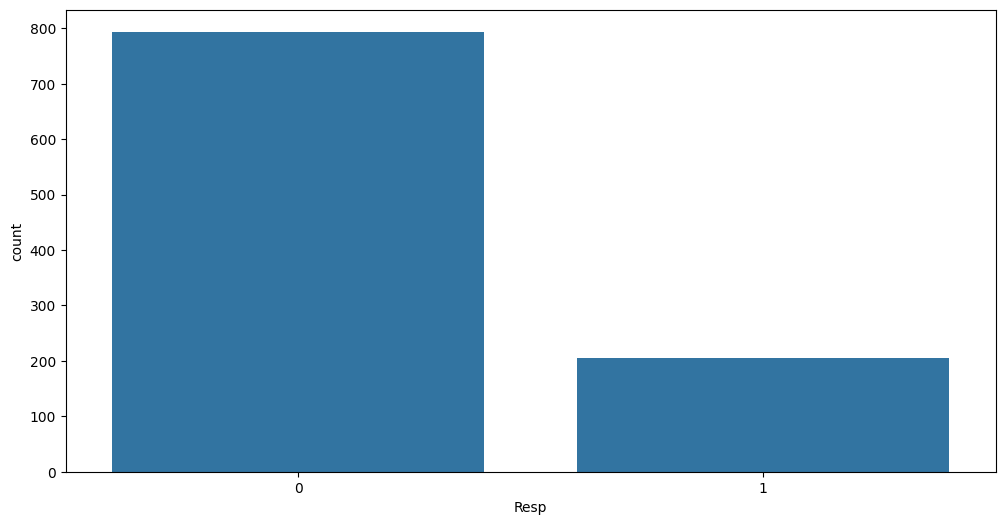

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.countplot(x="Resp",data=data)

In [18]:
data['Resp'].nunique() # gets unqiue values inside the column of data frame

2

In [19]:
data['Resp'].unique()

array([0, 1])

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [23]:
X = data[['VL-t0','CD4-t0']].values
Y = data[['Resp']].values

In [24]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2, random_state =2 )  #training set
model = LogisticRegression()
model.fit(X_train, Y_train)


C:\Users\marku\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
prediction=model.predict(X_test)

In [26]:
from sklearn.metrics import classification_report 
print(classification_report(Y_test, prediction))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90       164
           1       0.50      0.14      0.22        36

    accuracy                           0.82       200
   macro avg       0.67      0.55      0.56       200
weighted avg       0.78      0.82      0.78       200



In [33]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, Y_train)

C:\Users\marku\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [35]:
y_pred = classifier.predict(X_test)


print(classification_report(Y_test, y_pred))



              precision    recall  f1-score   support

           0       0.83      0.92      0.88       164
           1       0.32      0.17      0.22        36

    accuracy                           0.79       200
   macro avg       0.58      0.54      0.55       200
weighted avg       0.74      0.79      0.76       200

